In [4]:
""" Code for Section 0: Setup and Data Loading """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re # For parsing leg column names
import warnings
from typing import List, Dict, Optional, Tuple

# Suppress common warnings for cleaner output in a notebook
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

# --- Configuration ---
BASE_DIR = Path("/Users/barroca888/Downloads/Agenticfc/AgenticFC888") # Adjust if needed
PARLAY_RESULTS_PATH = BASE_DIR / "models/data/outputs/predictions/merged_V4_elite_parlay_results.parquet"
STRATEGY_GUIDE_PATH = BASE_DIR / "models/utils/files/best_strategy_per_market.csv" # From your provided example
NOTEBOOK_OUTPUT_DIR = BASE_DIR / "notebook_outputs/parlay_analysis"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis") # Default palette

# --- Load Data ---
print(f"--- Section 0: Loading Data ---")
# Load Parlay Results
try:
    assert PARLAY_RESULTS_PATH.exists(), f"Parlay results file not found: {PARLAY_RESULTS_PATH}"
    parlays_df = pd.read_parquet(PARLAY_RESULTS_PATH)
    print(f"Successfully loaded merged parlay results: {parlays_df.shape}")
except Exception as e:
    print(f"CRITICAL ERROR loading parlay results: {e}")
    # In a real notebook, you might raise the exception or sys.exit()
    parlays_df = pd.DataFrame() # Empty df to allow rest of notebook to run without crashing immediately

# Load Strategy Guide
try:
    assert STRATEGY_GUIDE_PATH.exists(), f"Strategy guide file not found: {STRATEGY_GUIDE_PATH}"
    strategy_df = pd.read_csv(STRATEGY_GUIDE_PATH)
    print(f"Successfully loaded strategy guide: {strategy_df.shape}")
except Exception as e:
    print(f"CRITICAL ERROR loading strategy guide: {e}")
    strategy_df = pd.DataFrame()

# --- Initial Data Inspection (Parlays) ---
if not parlays_df.empty:
    print("\n--- Parlay DataFrame Info ---")
    parlays_df.info(verbose=True, show_counts=True)
    print("\n--- Parlay DataFrame Head ---")
    print(parlays_df.head())
    print("\n--- Parlay DataFrame Describe ---")
    # Describe might be too verbose for all columns, select a few key ones
    # print(parlays_df[['num_legs', 'parlay_won', 'avg_prob']].describe())

    # Convert parlay_date to datetime objects if not already
    if 'parlay_date' in parlays_df.columns:
        try:
            parlays_df['parlay_date'] = pd.to_datetime(parlays_df['parlay_date'])
            print("\nConverted 'parlay_date' to datetime.")
        except Exception as e:
            print(f"Warning: Could not convert 'parlay_date' to datetime: {e}")
    else:
        print("Warning: 'parlay_date' column not found in parlays_df.")
else:
    print("Parlay DataFrame is empty. Cannot perform initial inspection.")

# --- Initial Data Inspection (Strategy) ---
if not strategy_df.empty:
    print("\n--- Strategy DataFrame Info ---")
    strategy_df.info()
    print("\n--- Strategy DataFrame Head ---")
    print(strategy_df.head())
    # Ensure crucial columns exist
    expected_strategy_cols = ['market', 'model_identifier', 'tradeoff_threshold']
    for col in expected_strategy_cols:
        assert col in strategy_df.columns, f"Missing crucial column '{col}' in strategy_df."
    print("Strategy DataFrame seems valid.")
else:
    print("Strategy DataFrame is empty. Cannot perform initial inspection.")

print(f"--- Section 0: Setup and Data Loading Complete ---")

--- Section 0: Loading Data ---
Successfully loaded merged parlay results: (66977, 35)
Successfully loaded strategy guide: (39, 6)

--- Parlay DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66977 entries, 0 to 66976
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   parlay_date         66977 non-null  object 
 1   num_legs            66977 non-null  int64  
 2   parlay_won          66977 non-null  int64  
 3   avg_prob            66977 non-null  float64
 4   parlay_country      66977 non-null  object 
 5   parlay_league       66977 non-null  object 
 6   market_combination  66977 non-null  object 
 7   leg1_match_id       66977 non-null  object 
 8   leg1_market         66977 non-null  object 
 9   leg1_model          66977 non-null  object 
 10  leg1_prob           66977 non-null  float64
 11  leg1_won            66977 non-null  int64  
 12  leg1_country        66977 non-null  ob

In [5]:
################################################################################

# %%
print(f"\n--- Section 1: Data Preprocessing & Enrichment ---")

legs_df = pd.DataFrame() # Initialize empty DataFrame

if not parlays_df.empty:
    # Determine the maximum number of legs from column names
    max_legs_observed = 0
    leg_pattern = re.compile(r"leg(\d+)_market") # Assuming '_market' is always present for a leg
    for col in parlays_df.columns:
        match = leg_pattern.match(col)
        if match:
            leg_num = int(match.group(1))
            if leg_num > max_legs_observed:
                max_legs_observed = leg_num
    
    if max_legs_observed == 0 and 'num_legs' in parlays_df.columns: # Fallback if parsing fails
        max_legs_observed = parlays_df['num_legs'].max() if not parlays_df['num_legs'].empty else 0


    print(f"Observed maximum number of legs in parlays_df: {max_legs_observed}")

    if max_legs_observed > 0:
        all_leg_data_frames: List[pd.DataFrame] = []
        
        # Add a unique parlay identifier if it doesn't exist
        if 'parlay_id' not in parlays_df.columns:
            parlays_df['parlay_id'] = parlays_df.index # Simple unique ID

        for i in range(1, max_legs_observed + 1):
            # Define columns for the current leg
            leg_market_col = f'leg{i}_market'
            leg_model_col = f'leg{i}_model'
            leg_prob_col = f'leg{i}_prob'
            leg_won_col = f'leg{i}_won'
            leg_country_col = f'leg{i}_country' # Assuming this naming
            leg_league_col = f'leg{i}_league'   # Assuming this naming

            # Check if essential columns for this leg exist
            required_leg_cols = [leg_market_col, leg_model_col, leg_prob_col, leg_won_col]
            if not all(col in parlays_df.columns for col in required_leg_cols):
                print(f"Info: Leg {i} data is incomplete or missing. Skipping this leg number for melting.")
                continue

            # Select common parlay-level info and leg-specific info
            current_leg_subset = parlays_df[
                ['parlay_id', 'parlay_date', 'num_legs', 'parlay_won', 'avg_prob'] + # Parlay level
                [leg_market_col, leg_model_col, leg_prob_col, leg_won_col] + # Leg specific (required)
                ([leg_country_col] if leg_country_col in parlays_df.columns else []) + # Optional
                ([leg_league_col] if leg_league_col in parlays_df.columns else [])    # Optional
            ].copy() # Use .copy() to avoid SettingWithCopyWarning

            # Remove rows where this leg's market is NaN (meaning the parlay had fewer than i legs)
            current_leg_subset.dropna(subset=[leg_market_col], inplace=True)
            if current_leg_subset.empty:
                continue

            # Rename leg-specific columns to generic names
            rename_map = {
                leg_market_col: 'market',
                leg_model_col: 'model_used',
                leg_prob_col: 'prob_at_bet',
                leg_won_col: 'leg_won',
            }
            if leg_country_col in current_leg_subset.columns:
                rename_map[leg_country_col] = 'leg_country'
            if leg_league_col in current_leg_subset.columns:
                rename_map[leg_league_col] = 'leg_league'

            current_leg_subset.rename(columns=rename_map, inplace=True)
            current_leg_subset['leg_number'] = i
            all_leg_data_frames.append(current_leg_subset)

        if all_leg_data_frames:
            legs_df = pd.concat(all_leg_data_frames, ignore_index=True)
            print(f"Successfully 'melted' parlays into leg-level data: {legs_df.shape}")
            
            # --- Data Cleaning on legs_df ---
            # Ensure correct types
            legs_df['prob_at_bet'] = pd.to_numeric(legs_df['prob_at_bet'], errors='coerce')
            legs_df['leg_won'] = pd.to_numeric(legs_df['leg_won'], errors='coerce').astype('Int64') # Use Int64 for nullable integers

            # Drop rows with NaN in critical leg columns after melting
            legs_df.dropna(subset=['market', 'model_used', 'prob_at_bet', 'leg_won'], inplace=True)
            print(f"Shape of legs_df after dropping NaNs in critical columns: {legs_df.shape}")

        else:
            print("No leg data could be extracted. legs_df will be empty.")
    else:
        print("Could not determine max_legs_observed or it's 0. Cannot melt parlay data.")

    # --- Merge Strategy Guide Information into legs_df ---
    if not legs_df.empty and not strategy_df.empty:
        legs_df = pd.merge(
            legs_df,
            strategy_df[['market', 'model_identifier', 'tradeoff_threshold']],
            left_on=['market', 'model_used'],
            right_on=['market', 'model_identifier'],
            how='left'
        )
        # Rename for clarity and drop redundant model_identifier
        legs_df.rename(columns={'tradeoff_threshold': 'entry_threshold_strategy'}, inplace=True)
        if 'model_identifier' in legs_df.columns: # It will be there after merge if successful
            legs_df.drop(columns=['model_identifier'], inplace=True)
        print(f"Merged strategy guide info into legs_df. New shape: {legs_df.shape}")
        print("Columns after merge:", legs_df.columns.tolist())
        # Check how many legs got a strategy threshold
        print(f"Number of legs with a matched strategy threshold: {legs_df['entry_threshold_strategy'].notna().sum()}")
        print(f"Number of legs WITHOUT a matched strategy threshold: {legs_df['entry_threshold_strategy'].isna().sum()}")

    elif legs_df.empty:
        print("legs_df is empty, cannot merge strategy guide.")
    else: # strategy_df is empty
        print("strategy_df is empty, cannot merge into legs_df.")
        
    if not legs_df.empty:
        print("\n--- Leg-Level DataFrame (legs_df) Head ---")
        print(legs_df.head())
        print("\n--- Leg-Level DataFrame (legs_df) Info ---")
        legs_df.info(verbose=True, show_counts=True)

else:
    print("Parlay DataFrame (parlays_df) is empty. Skipping Section 1.")

print(f"--- Section 1: Data Preprocessing & Enrichment Complete ---")



--- Section 1: Data Preprocessing & Enrichment ---
Observed maximum number of legs in parlays_df: 4
Successfully 'melted' parlays into leg-level data: (173340, 12)
Shape of legs_df after dropping NaNs in critical columns: (173340, 12)
Merged strategy guide info into legs_df. New shape: (198737, 13)
Columns after merge: ['parlay_id', 'parlay_date', 'num_legs', 'parlay_won', 'avg_prob', 'market', 'model_used', 'prob_at_bet', 'leg_won', 'leg_country', 'leg_league', 'leg_number', 'entry_threshold_strategy']
Number of legs with a matched strategy threshold: 198737
Number of legs WITHOUT a matched strategy threshold: 0

--- Leg-Level DataFrame (legs_df) Head ---
   parlay_id parlay_date  num_legs  parlay_won  avg_prob market  \
0          0  2010-07-31         2           0  0.802400    U45   
1          1  2010-07-31         2           0  0.802323    U45   
2          2  2010-07-31         2           1  0.755430    O15   
3          3  2010-07-31         2           0  0.802400    U45   


--- Section 2: Overall Parlay Performance Analysis ---
Total number of parlays analyzed: 66,977
Overall parlay win rate: 51.14%

--- Win Rate by Number of Legs ---
   num_legs  num_parlays  win_rate_pct
0         2        37924     61.143339
1         3        18720     44.065171
2         4        10333     27.271847


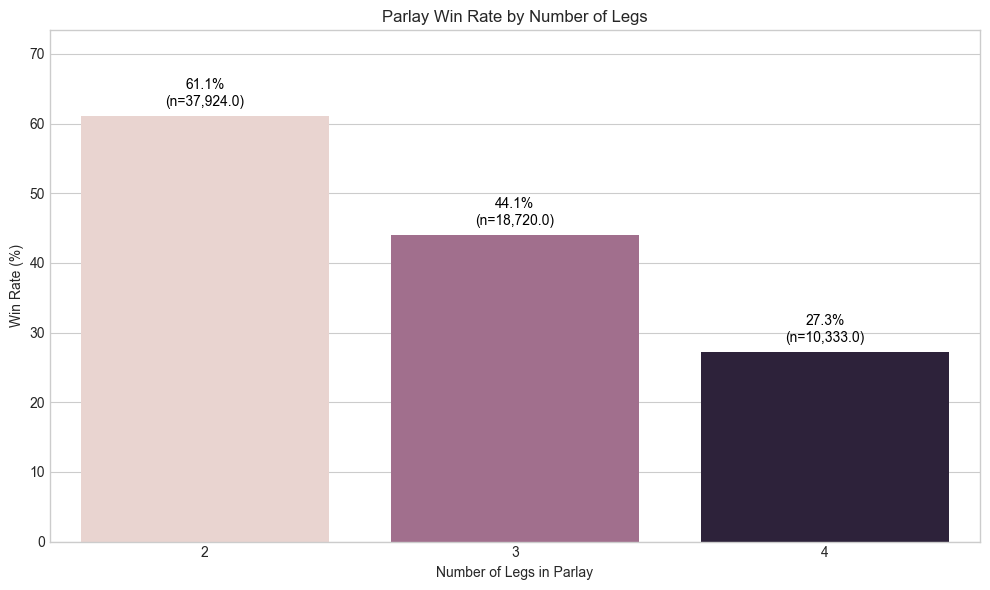


--- Parlay Avg. Probability vs. Actual Win Rate ---
  avg_prob_bin  num_parlays  actual_win_rate_pct
0  [0.5, 0.55)            0                  NaN
1  [0.55, 0.6)           18            16.666667
2  [0.6, 0.65)          444            10.810811
3  [0.65, 0.7)         3433            23.011943
4  [0.7, 0.75)         8872            33.171776
5  [0.75, 0.8)        29425            50.008496
6  [0.8, 0.85)        24586            63.584967
7  [0.85, 0.9)          183            60.109290
8  [0.9, 0.95)           16            81.250000
9  [0.95, 1.0)            0                  NaN


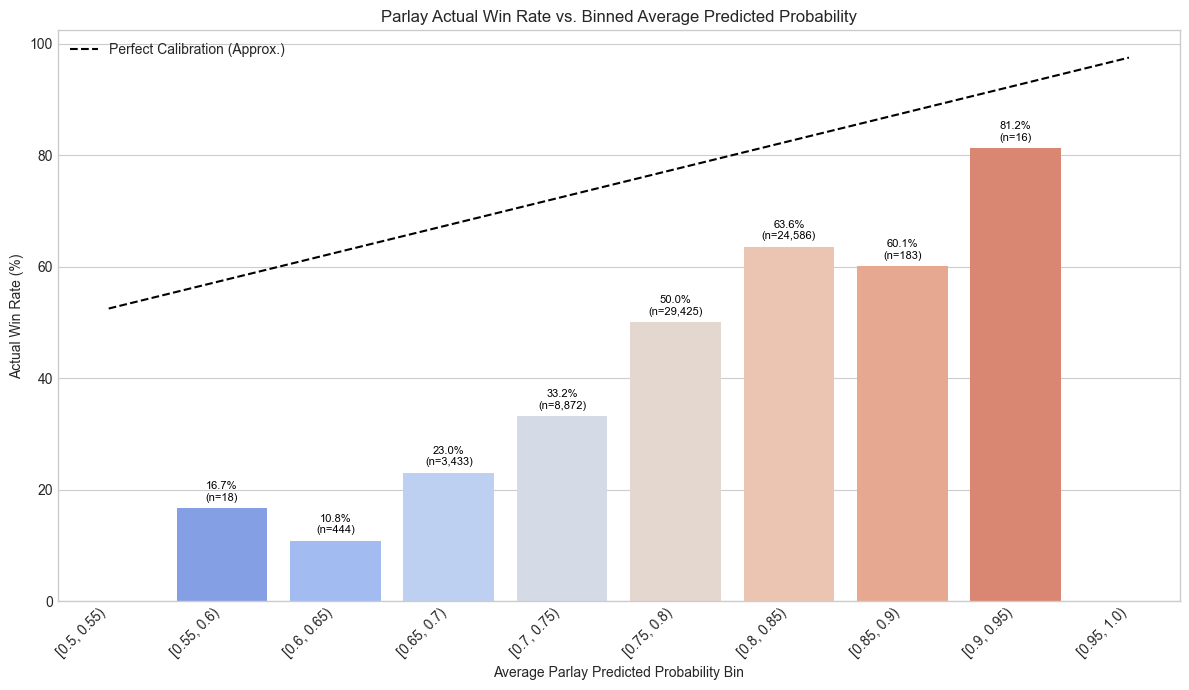

--- Section 2: Overall Parlay Performance Analysis Complete ---


In [6]:
print(f"\n--- Section 2: Overall Parlay Performance Analysis ---")

if not parlays_df.empty:
    total_parlays = len(parlays_df)
    overall_win_rate = parlays_df['parlay_won'].mean() * 100 if 'parlay_won' in parlays_df.columns else np.nan

    print(f"Total number of parlays analyzed: {total_parlays:,}")
    print(f"Overall parlay win rate: {overall_win_rate:.2f}%")

    # --- Win Rate by Number of Legs ---
    if 'num_legs' in parlays_df.columns and 'parlay_won' in parlays_df.columns:
        win_rate_by_legs = parlays_df.groupby('num_legs')['parlay_won'].agg(['count', 'mean']).reset_index()
        win_rate_by_legs['mean'] *= 100 # Convert to percentage
        win_rate_by_legs.rename(columns={'count': 'num_parlays', 'mean': 'win_rate_pct'}, inplace=True)
        
        print("\n--- Win Rate by Number of Legs ---")
        print(win_rate_by_legs)

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x='num_legs', y='win_rate_pct', data=win_rate_by_legs, hue='num_legs', dodge=False, legend=False)
        for i, row in win_rate_by_legs.iterrows():
            ax.text(i, row['win_rate_pct'] + 1, f"{row['win_rate_pct']:.1f}%\n(n={row['num_parlays']:,})",
                    color='black', ha="center", va="bottom")
        plt.title('Parlay Win Rate by Number of Legs')
        plt.xlabel('Number of Legs in Parlay')
        plt.ylabel('Win Rate (%)')
        plt.ylim(0, max(win_rate_by_legs['win_rate_pct'].max() * 1.2 if not win_rate_by_legs.empty else 0, 10)) # Dynamic Y-limit
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / 'parlay_win_rate_by_legs.png')
        plt.show()
        plt.close()
    else:
        print("Skipping 'Win Rate by Number of Legs' plot: 'num_legs' or 'parlay_won' missing.")

    # --- Average Probability vs. Actual Win Rate ---
    if 'avg_prob' in parlays_df.columns and 'parlay_won' in parlays_df.columns:
        parlays_df_prob_analysis = parlays_df.dropna(subset=['avg_prob', 'parlay_won'])
        if not parlays_df_prob_analysis.empty:
            # Create probability bins
            # Ensure bins cover the range of avg_prob, adjust step as needed
            min_p, max_p = parlays_df_prob_analysis['avg_prob'].min(), parlays_df_prob_analysis['avg_prob'].max()
            prob_bins = np.arange(max(0.0, np.floor(min_p*10)/10), min(1.01, np.ceil(max_p*10)/10 + 0.1), 0.05)
            if len(prob_bins) < 2: prob_bins = np.arange(0.0, 1.01, 0.1) # Fallback

            parlays_df_prob_analysis['avg_prob_bin'] = pd.cut(parlays_df_prob_analysis['avg_prob'], bins=prob_bins, right=False)
            
            prob_vs_winrate = parlays_df_prob_analysis.groupby('avg_prob_bin', observed=False)['parlay_won'].agg(['count', 'mean']).reset_index()
            prob_vs_winrate['mean'] *= 100
            prob_vs_winrate.rename(columns={'count': 'num_parlays', 'mean': 'actual_win_rate_pct'}, inplace=True)

            print("\n--- Parlay Avg. Probability vs. Actual Win Rate ---")
            print(prob_vs_winrate)

            plt.figure(figsize=(12, 7))
            ax = sns.barplot(x='avg_prob_bin', y='actual_win_rate_pct', data=prob_vs_winrate, hue='avg_prob_bin', dodge=False, legend=False, palette="coolwarm")
            # Add ideal calibration line (mid-point of bin)
            bin_mids = [(b.left + b.right) / 2 * 100 for b in prob_vs_winrate['avg_prob_bin'].cat.categories]
            plt.plot(range(len(bin_mids)), bin_mids, color='black', linestyle='--', label='Perfect Calibration (Approx.)')

            for i, row in prob_vs_winrate.iterrows():
                 ax.text(i, row['actual_win_rate_pct'] + 1, f"{row['actual_win_rate_pct']:.1f}%\n(n={row['num_parlays']:,})",
                         color='black', ha="center", va="bottom", fontsize=8)

            plt.title('Parlay Actual Win Rate vs. Binned Average Predicted Probability')
            plt.xlabel('Average Parlay Predicted Probability Bin')
            plt.ylabel('Actual Win Rate (%)')
            plt.xticks(rotation=45, ha="right")
            plt.legend()
            plt.tight_layout()
            plt.savefig(NOTEBOOK_OUTPUT_DIR / 'parlay_avg_prob_vs_win_rate.png')
            plt.show()
            plt.close()
        else:
            print("Skipping 'Avg. Prob vs Win Rate': No data after dropping NaNs.")
    else:
        print("Skipping 'Avg. Prob vs Win Rate' plot: 'avg_prob' or 'parlay_won' missing.")
else:
    print("Parlay DataFrame (parlays_df) is empty. Skipping Section 2.")

print(f"--- Section 2: Overall Parlay Performance Analysis Complete ---")


--- Section 3: Deep Dive into Individual Leg Performance (Revised) ---

--- Market Selection Performance (Leg Level) ---
Full market leg performance (including O0.5 for context):
        market  num_legs  legs_won  leg_win_rate_pct
3   HomeOrAway     43591     33242         76.258861
7          U45     43476     37418         86.065875
5          O15     42839     32383         75.592334
1        1XU45     17490     12068         68.999428
0        1XO15     13518      8354         61.799083
10       X2U45     12306      5896         47.911588
6          U35      9273      5870          63.30206
4   HomeOrDraw      8764      6492         74.075764
8        X2O15      4998      4986         99.759904
2      BTTSYes      2476      2476             100.0

Market leg performance (excluding O0.5, 12 O05, 1X O05 for plots/top lists):
        market  num_legs  legs_won  leg_win_rate_pct
3   HomeOrAway     43591     33242         76.258861
7          U45     43476     37418         86.065875


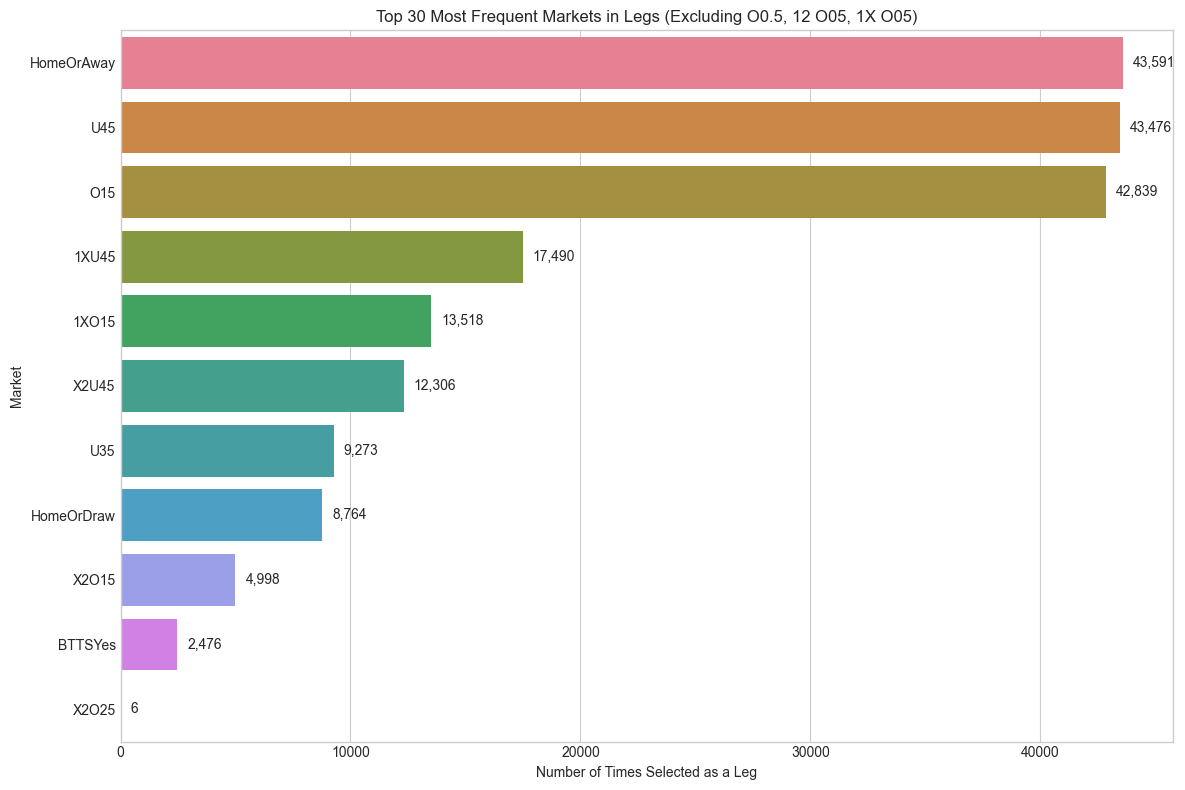

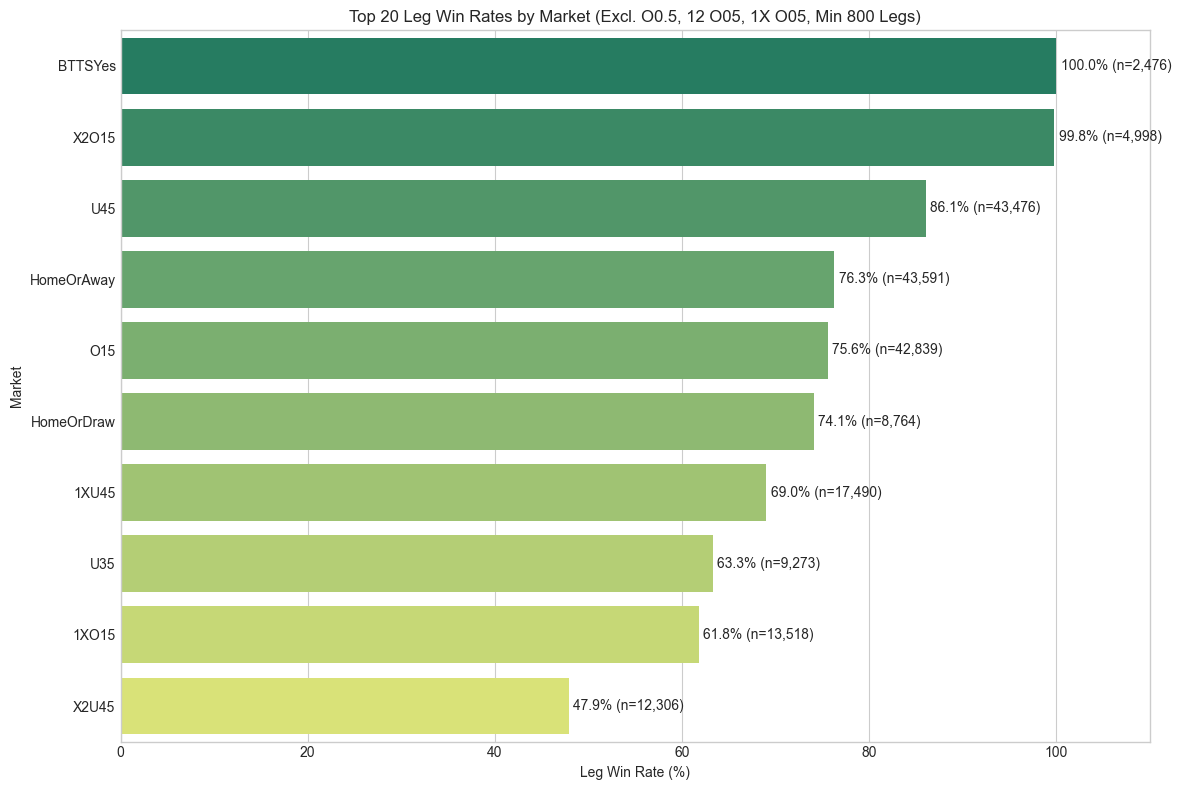


--- Model Performance (Leg Level) ---
                                model_used  num_legs  legs_won  \
3        monte_carlo_V1_NonPCA_WithOdds_L0     86430     65625   
0    gradient_boosting_V1_NonPCA_NoOdds_L0     61519     49786   
4                 poisson_V2_PCA_NoOdds_L0     31008     20422   
5         random_forest_V2_PCA_WithOdds_L0     12306      5896   
2     gradient_boosting_V2_PCA_WithOdds_L0      4998      4986   
1  gradient_boosting_V1_NonPCA_WithOdds_L0      2476      2476   

   leg_win_rate_pct  
3         75.928497  
0         80.927843  
4         65.860423  
5         47.911588  
2         99.759904  
1             100.0  


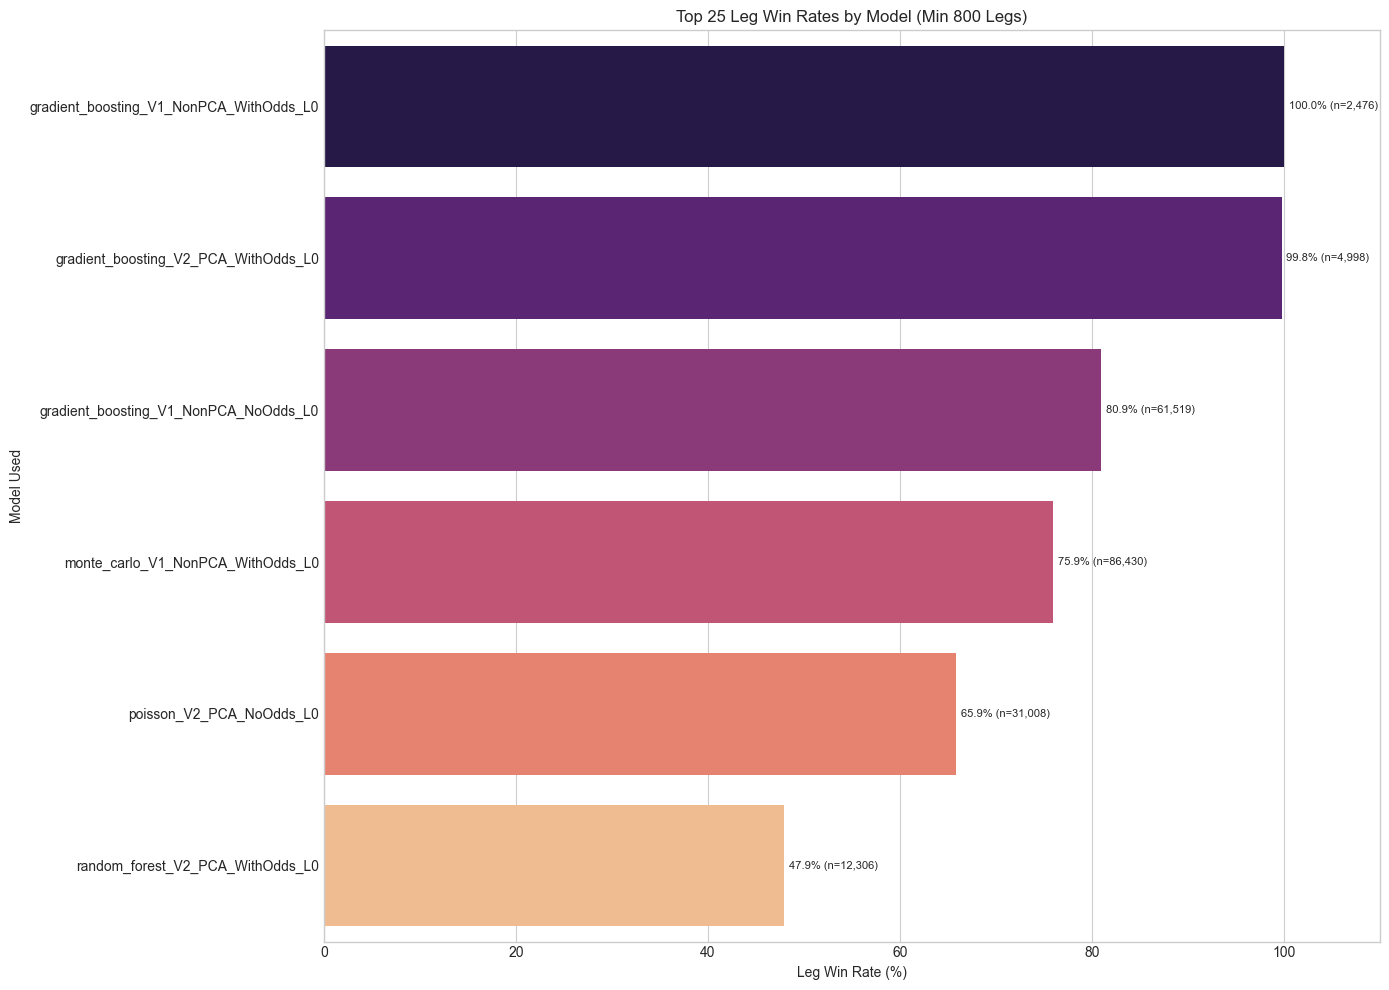


--- Model Performance per Market (Leg Level) ---
Top performing model-market pairs (sample, excluding O0.5, 12 O05, 1X O05):
        market                               model_used  num_legs  legs_won  \
0        1XO15                 poisson_V2_PCA_NoOdds_L0     13518      8354   
1        1XU45                 poisson_V2_PCA_NoOdds_L0     17490     12068   
2      BTTSYes  gradient_boosting_V1_NonPCA_WithOdds_L0      2476      2476   
3   HomeOrAway        monte_carlo_V1_NonPCA_WithOdds_L0     43591     33242   
4   HomeOrDraw    gradient_boosting_V1_NonPCA_NoOdds_L0      8764      6492   
5          O15        monte_carlo_V1_NonPCA_WithOdds_L0     42839     32383   
6          U35    gradient_boosting_V1_NonPCA_NoOdds_L0      9273      5870   
7          U45    gradient_boosting_V1_NonPCA_NoOdds_L0     43476     37418   
8        X2O15     gradient_boosting_V2_PCA_WithOdds_L0      4998      4986   
10       X2U45         random_forest_V2_PCA_WithOdds_L0     12306      5896   

    

/var/folders/41/_dw_pjd939j0k29gkmp2rlbw0000gn/T/ipykernel_901/134446127.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_impact = legs_with_threshold.groupby(diff_bins)['leg_won'].agg(['count', 'mean']).reset_index()


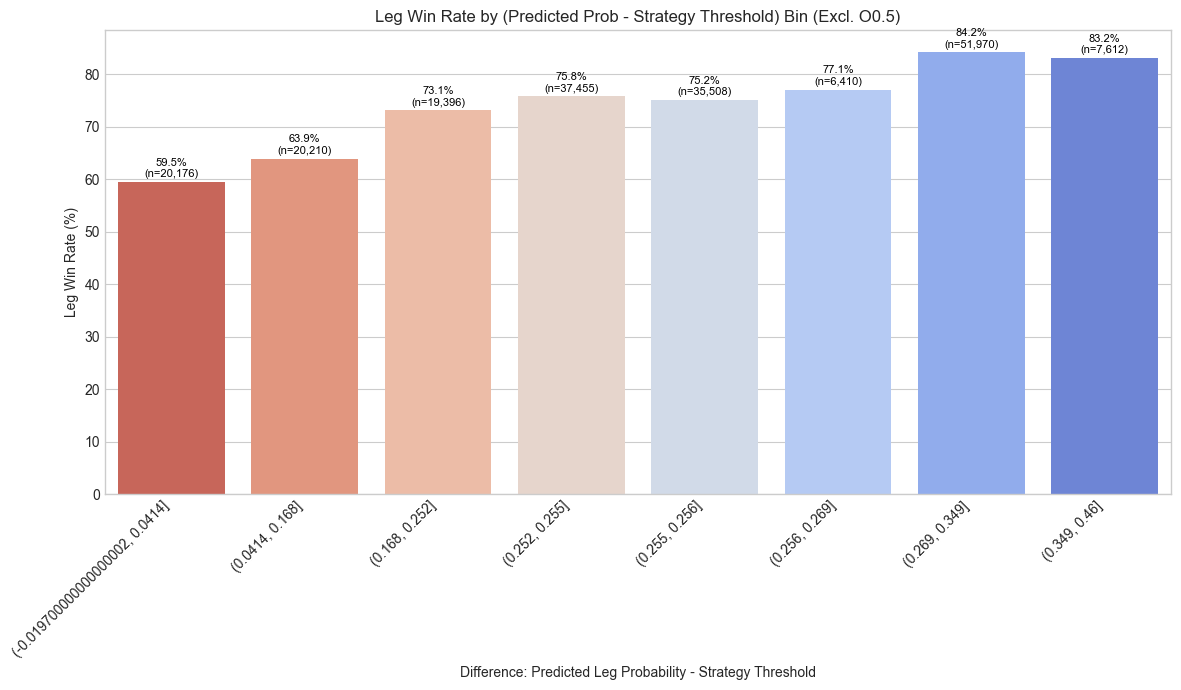

--- Section 3: Deep Dive into Individual Leg Performance (Revised) Complete ---


In [7]:

# %%
""" Code for Section 3: Deep Dive into Individual Leg Performance (Revised to Exclude O0.5 from plots) """
print(f"\n--- Section 3: Deep Dive into Individual Leg Performance (Revised) ---")

if not legs_df.empty:
    MIN_LEG_SAMPLES = 800 # Minimum samples for a group to be considered statistically relevant in plots

    # --- Market Selection Performance (Leg Level) ---
    print("\n--- Market Selection Performance (Leg Level) ---")
    market_leg_performance_all = legs_df.groupby('market')['leg_won'].agg(['count', 'sum', 'mean']).reset_index()
    market_leg_performance_all['mean'] *= 100
    market_leg_performance_all.rename(columns={'count': 'num_legs', 'sum':'legs_won', 'mean': 'leg_win_rate_pct'}, inplace=True)
    market_leg_performance_all = market_leg_performance_all.sort_values('num_legs', ascending=False)
    
    print("Full market leg performance (including O0.5 for context):")
    print(market_leg_performance_all.head(10)) # Show full list here for context

    # Create a filtered version for plotting, excluding O0.5, 12 O05, 1X O05
    excluded_markets = ['O05', '12O05', '1XO05']
    market_leg_performance_filtered = market_leg_performance_all[~market_leg_performance_all['market'].isin(excluded_markets)].copy()
    print("\nMarket leg performance (excluding O0.5, 12 O05, 1X O05 for plots/top lists):")
    print(market_leg_performance_filtered.head(10))


    # Plot frequency (excluding O0.5, 12 O05, 1X O05)
    plt.figure(figsize=(12, 8))
    top_n_markets_freq = 30
    data_to_plot_freq = market_leg_performance_filtered.head(top_n_markets_freq)
    if not data_to_plot_freq.empty:
        ax_freq = sns.barplot(x='num_legs', y='market', data=data_to_plot_freq, hue='market', dodge=False, legend=False, orient='h')
        plt.title(f'Top {top_n_markets_freq} Most Frequent Markets in Legs (Excluding O0.5, 12 O05, 1X O05)')
        plt.xlabel('Number of Times Selected as a Leg')
        plt.ylabel('Market')
        for i, bar in enumerate(ax_freq.patches):
            ax_freq.text(bar.get_width() + 0.01 * data_to_plot_freq['num_legs'].max(), bar.get_y() + bar.get_height() / 2.,
                     f"{int(data_to_plot_freq.iloc[i]['num_legs']):,}", ha='left', va='center')
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_market_frequency_filtered.png')
        plt.show()
        plt.close()
    else:
        print("Not enough data for market frequency plot (excluding O0.5, 12 O05, 1X O05).")


    # Plot win rate (excluding O0.5, 12 O05, 1X O05, for markets with enough samples)
    plt.figure(figsize=(12, 8))
    top_n_markets_win = 20
    data_to_plot_win = market_leg_performance_filtered[market_leg_performance_filtered['num_legs'] >= MIN_LEG_SAMPLES].sort_values('leg_win_rate_pct', ascending=False).head(top_n_markets_win)
    if not data_to_plot_win.empty:
        ax_win = sns.barplot(x='leg_win_rate_pct', y='market', data=data_to_plot_win, hue='market', dodge=False, legend=False, orient='h', palette='summer')
        plt.title(f'Top {top_n_markets_win} Leg Win Rates by Market (Excl. O0.5, 12 O05, 1X O05, Min {MIN_LEG_SAMPLES} Legs)')
        plt.xlabel('Leg Win Rate (%)')
        plt.ylabel('Market')
        for i, bar in enumerate(ax_win.patches):
            row = data_to_plot_win.iloc[i]
            ax_win.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
                         f"{row['leg_win_rate_pct']:.1f}% (n={int(row['num_legs']):,})", ha='left', va='center')
        plt.xlim(0, max(100, data_to_plot_win['leg_win_rate_pct'].max() * 1.1 if not data_to_plot_win.empty else 100))
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_market_win_rate_filtered.png')
        plt.show()
        plt.close()
    else:
        print(f"Not enough data for market win rate plot (excluding O0.5, 12 O05, 1X O05, min samples: {MIN_LEG_SAMPLES}).")


    # --- Model Performance (Leg Level) ---
    # This part remains the same as models are general
    print("\n--- Model Performance (Leg Level) ---")
    model_leg_performance = legs_df.groupby('model_used')['leg_won'].agg(['count', 'sum', 'mean']).reset_index()
    model_leg_performance['mean'] *= 100
    model_leg_performance.rename(columns={'count': 'num_legs', 'sum':'legs_won', 'mean': 'leg_win_rate_pct'}, inplace=True)
    model_leg_performance = model_leg_performance.sort_values('num_legs', ascending=False)
    print(model_leg_performance.head(10)) # Display top models by usage

    plt.figure(figsize=(14, 10)) # Potentially many models
    top_n_models_win = 25
    data_to_plot_model_win = model_leg_performance[model_leg_performance['num_legs'] >= MIN_LEG_SAMPLES].sort_values('leg_win_rate_pct', ascending=False).head(top_n_models_win)
    if not data_to_plot_model_win.empty:
        ax_model_win = sns.barplot(x='leg_win_rate_pct', y='model_used', data=data_to_plot_model_win, hue='model_used', dodge=False, legend=False, orient='h', palette='magma')
        plt.title(f'Top {top_n_models_win} Leg Win Rates by Model (Min {MIN_LEG_SAMPLES} Legs)')
        # ... (rest of the plotting code for model win rate as before)
        plt.xlabel('Leg Win Rate (%)')
        plt.ylabel('Model Used')
        for i, bar in enumerate(ax_model_win.patches):
            row = data_to_plot_model_win.iloc[i]
            ax_model_win.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
                     f"{row['leg_win_rate_pct']:.1f}% (n={int(row['num_legs']):,})", ha='left', va='center', fontsize=8)
        plt.xlim(0, max(100, data_to_plot_model_win['leg_win_rate_pct'].max() * 1.1 if not data_to_plot_model_win.empty else 100))
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_model_win_rate.png')
        plt.show()
        plt.close()
    else:
        print(f"Not enough data for model win rate plot (min samples: {MIN_LEG_SAMPLES}).")


    # --- Model Performance per Market (Excluding O0.5, 12 O05, 1X O05 from this specific display/focus) ---
    print("\n--- Model Performance per Market (Leg Level) ---")
    market_model_performance_all = legs_df.groupby(['market', 'model_used'])['leg_won'].agg(['count', 'sum', 'mean']).reset_index()
    market_model_performance_all['mean'] *= 100
    market_model_performance_all.rename(columns={'count': 'num_legs', 'sum':'legs_won', 'mean': 'leg_win_rate_pct'}, inplace=True)
    
    market_model_performance_filtered = market_model_performance_all[~market_model_performance_all['market'].isin(excluded_markets)].copy()

    # Filter for significant samples
    market_model_performance_filtered = market_model_performance_filtered[market_model_performance_filtered['num_legs'] >= MIN_LEG_SAMPLES / 2] 
    market_model_performance_sorted = market_model_performance_filtered.sort_values(['market', 'leg_win_rate_pct'], ascending=[True, False])
    
    print("Top performing model-market pairs (sample, excluding O0.5, 12 O05, 1X O05):")
    print(market_model_performance_sorted.head(20))
    
    best_model_per_market = market_model_performance_sorted.loc[market_model_performance_sorted.groupby('market')['leg_win_rate_pct'].idxmax()]
    print("\nBest performing model for each market (excl. O0.5, 12 O05, 1X O05, min samples applied):")
    print(best_model_per_market[['market', 'model_used', 'num_legs', 'leg_win_rate_pct']].sort_values('leg_win_rate_pct', ascending=False))


    # --- Impact of Strategy Entry Thresholds ---
    # Exclude O0.5, 12 O05, 1X O05 from threshold impact analysis
    if 'entry_threshold_strategy' in legs_df.columns:
        print("\n--- Impact of Strategy Entry Thresholds on Leg Performance ---")
        legs_with_threshold_all = legs_df.dropna(subset=['entry_threshold_strategy', 'prob_at_bet'])
        # Filter out O0.5, 12 O05, 1X O05
        legs_with_threshold = legs_with_threshold_all[~legs_with_threshold_all['market'].isin(excluded_markets)].copy()
        
        if not legs_with_threshold.empty:
            legs_with_threshold['prob_vs_threshold_diff'] = legs_with_threshold['prob_at_bet'] - legs_with_threshold['entry_threshold_strategy']
            
            # Bin the difference
            # Handle potential for not enough unique values for qcut
            try:
                diff_bins = pd.qcut(legs_with_threshold['prob_vs_threshold_diff'], q=10, duplicates='drop') # 10 quantiles
            except ValueError: # Happens if not enough unique values for 10 quantiles
                print("Warning: Not enough unique values for 10 quantiles in 'prob_vs_threshold_diff'. Using 5 or fewer.")
                try:
                    diff_bins = pd.qcut(legs_with_threshold['prob_vs_threshold_diff'], q=5, duplicates='drop')
                except ValueError:
                    diff_bins = legs_with_threshold['prob_vs_threshold_diff'] # Use raw values if qcut fails entirely

            threshold_impact = legs_with_threshold.groupby(diff_bins)['leg_won'].agg(['count', 'mean']).reset_index()
            threshold_impact['mean'] *= 100
            threshold_impact.rename(columns={'count': 'num_legs', 'mean': 'leg_win_rate_pct', 'prob_vs_threshold_diff': 'prob_minus_threshold_bin'}, inplace=True)
            
            print(threshold_impact)

            if not threshold_impact.empty and threshold_impact['prob_minus_threshold_bin'].nunique() > 1: # Ensure there's something to plot
                plt.figure(figsize=(12, 7))
                ax = sns.barplot(x='prob_minus_threshold_bin', y='leg_win_rate_pct', data=threshold_impact, hue='prob_minus_threshold_bin', dodge=False, legend=False, palette='coolwarm_r')
                # ... (rest of the plotting code for threshold impact as before)
                plt.title('Leg Win Rate by (Predicted Prob - Strategy Threshold) Bin (Excl. O0.5)')
                plt.xlabel('Difference: Predicted Leg Probability - Strategy Threshold')
                plt.ylabel('Leg Win Rate (%)')
                plt.xticks(rotation=45, ha="right")
                for i, row in threshold_impact.iterrows():
                     ax.text(i, row['leg_win_rate_pct'] + 0.5, f"{row['leg_win_rate_pct']:.1f}%\n(n={row['num_legs']:,})",
                             color='black', ha="center", va="bottom", fontsize=8)
                plt.tight_layout()
                plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_prob_vs_threshold_impact_no_o05.png')
                plt.show()
                plt.close()
            else:
                print("Not enough distinct bins or data to plot threshold impact (excl. O0.5).")
        else:
            print("No leg data (excl. O0.5) with both strategy threshold and predicted probability.")
    else:
        print("Column 'entry_threshold_strategy' not found in legs_df. Skipping threshold impact analysis.")

else:
    print("Leg-Level DataFrame (legs_df) is empty. Skipping Section 3.")

print(f"--- Section 3: Deep Dive into Individual Leg Performance (Revised) Complete ---")

In [25]:
print(f"\n--- Section 4: Parlay Composition Insights ---")
# This section can be complex. We'll focus on a few key analyses.

if not parlays_df.empty and not legs_df.empty:
    # --- Performance of Parlays Containing Specific High-Performing Markets/Models ---
    # Identify top N markets/models from Section 3 to analyze further
    # For example, get top 3 markets by leg win rate from market_leg_performance
    if 'market_leg_performance' in locals() and not market_leg_performance.empty:
        top_markets_for_parlay_analysis = market_leg_performance[market_leg_performance['num_legs'] >= MIN_LEG_SAMPLES].sort_values('leg_win_rate_pct', ascending=False).head(3)['market'].tolist()
        
        print(f"\nAnalyzing parlays containing top markets: {top_markets_for_parlay_analysis}")
        for top_market in top_markets_for_parlay_analysis:
            # Find parlay_ids that have at least one leg with this market
            parlay_ids_with_market = legs_df[legs_df['market'] == top_market]['parlay_id'].unique()
            parlays_containing_market = parlays_df[parlays_df['parlay_id'].isin(parlay_ids_with_market)]
            
            if not parlays_containing_market.empty:
                win_rate = parlays_containing_market['parlay_won'].mean() * 100
                count = len(parlays_containing_market)
                print(f"Parlays containing market '{top_market}': Count={count:,}, Win Rate={win_rate:.2f}%")
            else:
                print(f"No parlays found containing market '{top_market}'.")
    else:
        print("market_leg_performance not available for parlay composition analysis.")

    # --- Common Market Combinations in Winning Parlays (Focus on 2-leg parlays for simplicity) ---
    print("\n--- Common Market Combinations in Winning 2-Leg Parlays ---")
    winning_2_leg_parlays = parlays_df[(parlays_df['parlay_won'] == 1) & (parlays_df['num_legs'] == 2)].copy()
    
    if not winning_2_leg_parlays.empty and all(c in winning_2_leg_parlays.columns for c in ['leg1_market', 'leg2_market']):
        # Create a canonical representation of the market pair (sorted tuple)
        winning_2_leg_parlays['market_pair'] = winning_2_leg_parlays.apply(
            lambda row: tuple(sorted((row['leg1_market'], row['leg2_market']))), axis=1
        )
        common_winning_pairs = winning_2_leg_parlays['market_pair'].value_counts().reset_index()
        common_winning_pairs.columns = ['market_pair', 'count_in_wins']
        
        print("Top 10 most common market pairs in WINNING 2-leg parlays:")
        print(common_winning_pairs.head(10))

        # To get win rate of these specific pairs, we need to look at ALL 2-leg parlays
        all_2_leg_parlays = parlays_df[parlays_df['num_legs'] == 2].copy()
        if not all_2_leg_parlays.empty and all(c in all_2_leg_parlays.columns for c in ['leg1_market', 'leg2_market']):
            all_2_leg_parlays['market_pair'] = all_2_leg_parlays.apply(
                lambda row: tuple(sorted((row['leg1_market'], row['leg2_market']))), axis=1
            )
            # Calculate total occurrences and total wins for each pair
            pair_performance = all_2_leg_parlays.groupby('market_pair')['parlay_won'].agg(['count', 'sum']).reset_index()
            pair_performance.rename(columns={'count': 'total_parlays_with_pair', 'sum': 'total_wins_with_pair'}, inplace=True)
            pair_performance['win_rate_pct'] = (pair_performance['total_wins_with_pair'] / pair_performance['total_parlays_with_pair']) * 100
            
            pair_performance = pair_performance.sort_values('win_rate_pct', ascending=False)
            print("\nPerformance of specific 2-leg market combinations (min 20 occurrences):")
            print(pair_performance[pair_performance['total_parlays_with_pair'] >= 20].head(15))
        else:
            print("Not enough data or missing leg market columns in all 2-leg parlays.")
    else:
        print("No winning 2-leg parlays or missing leg market columns for combination analysis.")

else:
    print("Parlay or Leg DataFrames are empty. Skipping Section 4.")
print(f"--- Section 4: Parlay Composition Insights Complete ---")


--- Section 4: Parlay Composition Insights ---
Parlay or Leg DataFrames are empty. Skipping Section 4.
--- Section 4: Parlay Composition Insights Complete ---


In [26]:
print(f"\n--- Section 5: League and Country Analysis ---")
MIN_SAMPLES_GEO = 50 # Min samples for country/league plots

if not parlays_df.empty:
    print("\n--- Parlay Win Rate by Parlay Country ---")
    if 'parlay_country' in parlays_df.columns:
        country_parlay_perf = parlays_df.groupby('parlay_country')['parlay_won'].agg(['count', 'mean']).reset_index()
        country_parlay_perf['mean'] *= 100
        country_parlay_perf.rename(columns={'count': 'num_parlays', 'mean': 'win_rate_pct'}, inplace=True)
        
        plot_data_country = country_parlay_perf[country_parlay_perf['num_parlays'] >= MIN_SAMPLES_GEO].sort_values('win_rate_pct', ascending=False).head(15)
        if not plot_data_country.empty:
            plt.figure(figsize=(12, 8))
            ax = sns.barplot(x='win_rate_pct', y='parlay_country', data=plot_data_country, hue='parlay_country', dodge=False, legend=False, orient='h', palette='cubehelix')
            plt.title(f'Top Parlay Win Rates by Country (Min {MIN_SAMPLES_GEO} Parlays)')
            plt.xlabel('Parlay Win Rate (%)')
            plt.ylabel('Parlay Country (Primary leg country)')
            for i, bar in enumerate(ax.patches):
                row = plot_data_country.iloc[i]
                ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
                         f"{row['win_rate_pct']:.1f}% (n={int(row['num_parlays']):,})", ha='left', va='center')
            plt.xlim(0, max(100, plot_data_country['win_rate_pct'].max() * 1.1 if not plot_data_country.empty else 100))
            plt.tight_layout()
            plt.savefig(NOTEBOOK_OUTPUT_DIR / 'parlay_win_rate_by_country.png')
            plt.show()
            plt.close()
        else:
            print(f"Not enough data for parlay win rate by country plot (min samples: {MIN_SAMPLES_GEO}).")
    else:
        print("'parlay_country' column not found in parlays_df.")

if not legs_df.empty:
    print("\n--- Leg Win Rate by Leg Country ---")
    if 'leg_country' in legs_df.columns: # Assuming leg_country was created during melt
        country_leg_perf = legs_df.groupby('leg_country')['leg_won'].agg(['count', 'mean']).reset_index()
        country_leg_perf['mean'] *= 100
        country_leg_perf.rename(columns={'count': 'num_legs', 'mean': 'leg_win_rate_pct'}, inplace=True)
        
        plot_data_leg_country = country_leg_perf[country_leg_perf['num_legs'] >= MIN_SAMPLES_GEO].sort_values('leg_win_rate_pct', ascending=False).head(15)
        if not plot_data_leg_country.empty:
            plt.figure(figsize=(12, 8))
            ax = sns.barplot(x='leg_win_rate_pct', y='leg_country', data=plot_data_leg_country, hue='leg_country', dodge=False, legend=False, orient='h', palette='Spectral')
            plt.title(f'Top Leg Win Rates by Leg Country (Min {MIN_SAMPLES_GEO} Legs)')
            plt.xlabel('Leg Win Rate (%)')
            plt.ylabel('Leg Country')
            for i, bar in enumerate(ax.patches):
                row = plot_data_leg_country.iloc[i]
                ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
                         f"{row['leg_win_rate_pct']:.1f}% (n={int(row['num_legs']):,})", ha='left', va='center')
            plt.xlim(0, max(100, plot_data_leg_country['leg_win_rate_pct'].max() * 1.1 if not plot_data_leg_country.empty else 100))
            plt.tight_layout()
            plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_win_rate_by_leg_country.png')
            plt.show()
            plt.close()
        else:
            print(f"Not enough data for leg win rate by leg_country plot (min samples: {MIN_SAMPLES_GEO}).")

    # Similar analysis can be done for 'parlay_league' and 'leg_league' if those columns exist and are populated.
    # Example for 'leg_league':
    if 'leg_league' in legs_df.columns:
        print("\n--- Leg Win Rate by Leg League ---")
        league_leg_perf = legs_df.groupby('leg_league')['leg_won'].agg(['count', 'mean']).reset_index()
        league_leg_perf['mean'] *= 100
        league_leg_perf.rename(columns={'count': 'num_legs', 'mean': 'leg_win_rate_pct'}, inplace=True)
        
        plot_data_leg_league = league_leg_perf[league_leg_perf['num_legs'] >= MIN_SAMPLES_GEO].sort_values('leg_win_rate_pct', ascending=False).head(20)
        if not plot_data_leg_league.empty:
            plt.figure(figsize=(14, 10))
            ax = sns.barplot(x='leg_win_rate_pct', y='leg_league', data=plot_data_leg_league, hue='leg_league', dodge=False, legend=False, orient='h', palette='terrain')
            plt.title(f'Top Leg Win Rates by Leg League (Min {MIN_SAMPLES_GEO} Legs)')
            # ... (add labels and savefig as above)
            plt.tight_layout()
            plt.savefig(NOTEBOOK_OUTPUT_DIR / 'leg_win_rate_by_leg_league.png')
            plt.show()
            plt.close()
        else:
             print(f"Not enough data for leg win rate by leg_league plot (min samples: {MIN_SAMPLES_GEO}).")


else:
    print("Parlay or Leg DataFrames are empty. Skipping Section 5.")
print(f"--- Section 5: League and Country Analysis Complete ---")


--- Section 5: League and Country Analysis ---
Parlay or Leg DataFrames are empty. Skipping Section 5.
--- Section 5: League and Country Analysis Complete ---


In [27]:
print(f"\n--- Section 6: Efficiency Thresholds and Parlay Construction ---")

if not legs_df.empty and not strategy_df.empty and 'entry_threshold_strategy' in legs_df.columns:
    print("\n--- Revisit Strategy Guide Thresholds vs. Observed Performance ---")
    # We already plotted 'prob_vs_threshold_diff' impact in Section 3.
    # Here, let's look at market-model pairs and their performance relative to strategy thresholds.
    
    legs_with_strat = legs_df.dropna(subset=['entry_threshold_strategy', 'prob_at_bet', 'market', 'model_used'])
    
    if not legs_with_strat.empty:
        # Compare actual win rate vs. what the strategy guide might imply
        # This is more qualitative without knowing the "expected" win rate at threshold.
        
        # Example: For each market-model in strategy guide, what's the actual win rate of legs
        # that were selected using a prob_at_bet >= entry_threshold_strategy?
        
        performance_at_strategy_thresholds = legs_with_strat[
            legs_with_strat['prob_at_bet'] >= legs_with_strat['entry_threshold_strategy']
        ].groupby(['market', 'model_used', 'entry_threshold_strategy'])['leg_won'].agg(
            observed_leg_count = 'count',
            observed_win_rate_pct = lambda x: x.mean() * 100
        ).reset_index()
        
        performance_at_strategy_thresholds = performance_at_strategy_thresholds[
            performance_at_strategy_thresholds['observed_leg_count'] >= MIN_LEG_SAMPLES / 2 # Min samples for this comparison
        ].sort_values('observed_win_rate_pct', ascending=False)
        
        print("\nObserved leg win rates for market-model pairs (when prob_at_bet >= strategy threshold):")
        print(performance_at_strategy_thresholds.head(20))
        
        # Identify market-model pairs where observed win rate is significantly different from
        # what might be "expected" (e.g., if you expect win rate to be close to the threshold itself, or higher).
        # This requires a baseline expectation. For now, just list them.
        # You could merge this with the original strategy_df's 'win_rate_at_tradeoff' if you want a direct comparison.
        if 'win_rate_at_tradeoff' in strategy_df.columns:
            comp_df = pd.merge(performance_at_strategy_thresholds,
                               strategy_df[['market','model_identifier','win_rate_at_tradeoff']],
                               left_on=['market','model_used'],
                               right_on=['market','model_identifier'],
                               how='left')
            comp_df['observed_vs_strategy_win_diff'] = comp_df['observed_win_rate_pct'] - comp_df['win_rate_at_tradeoff']
            print("\nComparison: Observed Leg Win Rate vs. Strategy Guide's 'win_rate_at_tradeoff'")
            print(comp_df[['market','model_used','entry_threshold_strategy','observed_leg_count','win_rate_at_tradeoff','observed_win_rate_pct','observed_vs_strategy_win_diff']].sort_values('observed_vs_strategy_win_diff', ascending=False).head(20))

    else:
        print("Not enough data in legs_df with strategy thresholds to analyze.")
else:
    print("legs_df, strategy_df, or 'entry_threshold_strategy' column missing. Skipping Section 6.")

print(f"--- Section 6: Efficiency Thresholds and Parlay Construction Complete ---")


--- Section 6: Efficiency Thresholds and Parlay Construction ---
legs_df, strategy_df, or 'entry_threshold_strategy' column missing. Skipping Section 6.
--- Section 6: Efficiency Thresholds and Parlay Construction Complete ---


In [28]:
# %% [markdown]
# ## 3.5. Detailed Calibration for Core Market-Model Pairs
#
# Before defining our "Elite Leg Strategy" for the next parlay generation run,
# let's examine the calibration of our identified "Best Performing Models" for
# their respective "Core Parlay Markets" in more detail. This will help us set
# more informed `min_elite_threshold` values.
#
# We will focus on the probability ranges that yield high actual leg win rates.
################################################################################

# %%
""" Code for Notebook Section 3.5: Detailed Calibration for Core Market-Model Pairs """
print(f"\n--- Section 3.5: Detailed Calibration for Core Market-Model Pairs ---")

if not legs_df.empty:
    # Define your Core Parlay Markets and their current best models
    # (This comes from your refined Section 3 output)
    CORE_MARKET_MODEL_PAIRS = {
        'U45': 'gradient_boosting_V1_NonPCA_NoOdds_L0',
        'O15': 'monte_carlo_V1_NonPCA_WithOdds_L0',
        'HomeOrAway': 'monte_carlo_V1_NonPCA_WithOdds_L0',
        'HomeOrDraw': 'gradient_boosting_V1_NonPCA_NoOdds_L0',
        'U35': 'gradient_boosting_V1_NonPCA_NoOdds_L0',
        '1XU45': 'poisson_V2_PCA_NoOdds_L0',
        # Add 'DrawOrAway' if you're still considering it, or other promising pairs
        # 'DrawOrAway': 'random_forest_V2_PCA_WithOdds_L0',
    }
    print(f"Analyzing calibration for {len(CORE_MARKET_MODEL_PAIRS)} core market-model pairs.")

    elite_threshold_candidates = {} # To store suggested elite thresholds

    for market, model_name in CORE_MARKET_MODEL_PAIRS.items():
        print(f"\n--- Calibration Analysis for Market: {market}, Model: {model_name} ---")
        
        # Filter legs_df for this specific pair
        pair_legs_df = legs_df[(legs_df['market'] == market) & (legs_df['model_used'] == model_name)].copy()
        
        if pair_legs_df.empty:
            print(f"No data found for {market} - {model_name}. Skipping.")
            continue
        
        pair_legs_df.dropna(subset=['prob_at_bet', 'leg_won'], inplace=True)
        if len(pair_legs_df) < MIN_LEG_SAMPLES: # Use MIN_LEG_SAMPLES from earlier
             print(f"Not enough samples ({len(pair_legs_df)}) for {market} - {model_name} after NaN drop. Skipping detailed plot.")
             continue

        # Create fine-grained probability bins for this specific pair
        # Focus on the higher probability ranges, e.g., 0.5 upwards
        prob_bins_fine = np.arange(0.5, 1.01, 0.05) # Bins of 0.05
        
        pair_legs_df['prob_at_bet_bin'] = pd.cut(pair_legs_df['prob_at_bet'], bins=prob_bins_fine, right=False, include_lowest=True)
        
        calibration_data = pair_legs_df.groupby('prob_at_bet_bin', observed=True)['leg_won'].agg(
            num_legs_in_bin = 'count',
            actual_win_rate_pct = lambda x: x.mean() * 100
        ).reset_index()
        
        print(calibration_data)

        # Determine a suggested elite threshold for this pair
        # Logic: Find the lowest probability bin where actual_win_rate_pct consistently stays above a target (e.g., 70% or 75%)
        TARGET_ELITE_WIN_RATE = 75.0 # Define your target win rate for an "elite" leg
        suggested_threshold = np.nan

        # Iterate through bins from lowest to highest probability
        for _, row in calibration_data.sort_values(by='prob_at_bet_bin').iterrows():
            if row['num_legs_in_bin'] >= MIN_LEG_SAMPLES / 5: # Ensure bin has some reasonable number of samples
                if row['actual_win_rate_pct'] >= TARGET_ELITE_WIN_RATE:
                    suggested_threshold = row['prob_at_bet_bin'].left # Take the start of that bin
                    break # Found the first bin meeting the criteria
        
        if pd.notna(suggested_threshold):
            elite_threshold_candidates[(market, model_name)] = suggested_threshold
            print(f"Suggested elite threshold for {market} - {model_name}: >= {suggested_threshold:.2f} (achieves ~{calibration_data[calibration_data['prob_at_bet_bin'].apply(lambda b: b.left == suggested_threshold)]['actual_win_rate_pct'].iloc[0]:.1f}% win rate in that bin)")
        else:
            print(f"Could not determine a clear elite threshold for {market} - {model_name} to achieve {TARGET_ELITE_WIN_RATE}% win rate.")


        # Plotting the calibration for this pair
        if calibration_data['prob_at_bet_bin'].nunique() > 1:
            plt.figure(figsize=(10, 6))
            ax = sns.barplot(x='prob_at_bet_bin', y='actual_win_rate_pct', data=calibration_data, hue='prob_at_bet_bin', legend=False, palette='viridis_r')
            
            # Add perfect calibration line (using bin midpoints)
            bin_mids_fine = [(b.left + b.right) / 2 * 100 for b in calibration_data['prob_at_bet_bin'].cat.categories if isinstance(b, pd.Interval)]
            if bin_mids_fine:
                 plt.plot(range(len(bin_mids_fine)), bin_mids_fine, color='red', linestyle='--', label='Perfect Calibration')

            plt.axhline(y=TARGET_ELITE_WIN_RATE, color='grey', linestyle=':', label=f'Target Elite WR ({TARGET_ELITE_WIN_RATE}%)')

            for i, row in calibration_data.iterrows():
                 ax.text(i, row['actual_win_rate_pct'] + 1, f"{row['actual_win_rate_pct']:.1f}%\n(n={row['num_legs_in_bin']:,})",
                         color='black', ha="center", va="bottom", fontsize=8)
            
            plt.title(f'Leg Calibration: Market={market}, Model={model_name}')
            plt.xlabel('Predicted Probability Bin (prob_at_bet)')
            plt.ylabel('Actual Leg Win Rate (%)')
            plt.xticks(rotation=45, ha="right")
            plt.legend()
            plt.ylim(0, 105)
            plt.tight_layout()
            plt.savefig(NOTEBOOK_OUTPUT_DIR / f'calibration_{market}_{model_name.replace("/", "_")}.png') # Sanitize model name for filename
            plt.show()
            plt.close()
        else:
            print(f"Not enough distinct bins to plot calibration for {market} - {model_name}.")
            
    print("\n--- Suggested Elite Threshold Candidates ---")
    for (mkt, mdl), thr in elite_threshold_candidates.items():
        print(f"Market: {mkt}, Model: {mdl}, Suggested Min Elite Threshold: {thr:.3f}")

else:
    print("Leg-Level DataFrame (legs_df) is empty. Skipping Section 3.5.")

print(f"--- Section 3.5: Detailed Calibration for Core Market-Model Pairs Complete ---")
################################################################################



--- Section 3.5: Detailed Calibration for Core Market-Model Pairs ---
Leg-Level DataFrame (legs_df) is empty. Skipping Section 3.5.
--- Section 3.5: Detailed Calibration for Core Market-Model Pairs Complete ---
